In [25]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

In [26]:
meta_models = {
    "all": {
        "dataset": "data/metafeatures_dataset_with_best.csv",
        "train": make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42)),
    },
    "me1": {
        "dataset": "data/metafeatures_selected_with_best_subset_selection_filter_milp.csv",
        "train": DecisionTreeClassifier(random_state=42),
        },
    "me2": {
        "dataset": "data/metafeatures_selected_with_knapsack_problem_ilp.csv",
        "train": DecisionTreeClassifier(random_state=42),
    },
    "me3": {
        "dataset": "data/metafeatures_selected_with_correlation_penalized_by_milp.csv",
        "train": DecisionTreeClassifier(random_state=42),
    },
    "ma1": {
        "dataset": "data/metafeatures_selected_with_ag_1_classico_binario.csv",
        "train": ExtraTreesClassifier(
            n_estimators=180,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        ),
    },
    "ma2":
    {
        "dataset": "data/metafeatures_selected_with_ag_2_guiado_por_mi_busca_local.csv",
        "train": ExtraTreesClassifier(
            n_estimators=180,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        ),
    },
    "ma3": {
        "dataset": "data/metafeatures_selected_with_ag_3_compacto_esparso.csv",
        "train": ExtraTreesClassifier(
            n_estimators=180,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        ),
    },
    "ah1": {
        "dataset": "data/metafeatures_selected_with_hybrid_ag_1_classico_binario.csv",
        "train": ExtraTreesClassifier(
            n_estimators=180,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        ),
    },
    "ah2": {
        "dataset": "data/metafeatures_selected_with_hybrid_ag_2_guiado_por_mi_busca_local.csv",
        "train": ExtraTreesClassifier(
            n_estimators=180,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        ),
    },
    "ah3": {
        "dataset": "data/metafeatures_selected_with_hybrid_ag_3_compacto_esparso.csv",
        "train": ExtraTreesClassifier(
            n_estimators=180,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        ),
    },
}

In [27]:

def execute_meta_model(data, model, key, global_dataset):
    """
    Se for me[numero] e all faça com leaveoneout
    se não faça com StratifiedKFold com k igual 5
    return: acuracia e a predição com todos os valores igual no metodo exato
    """
    summary_of_predictions = {
        'Dataset':[],
        'Best clf (true)':[],
        'Perf of best clf (true)':[],
        'Best clf (pred)':[],
        'Perf of best clf (pred)':[]
    }
    
    X = data.drop(columns=['Dataset', 'Best'])
    y = data['Best']
    X = X.fillna(0)
    
    y_pred_list = []
    y_true_list = []
    
    if key.startswith('me') or key == 'all':
        cv = LeaveOneOut()
    else:
        class_counts = y.value_counts()
        min_class = class_counts.min()
        k = min(5, min_class)
        if k < 2:
            cv = KFold(n_splits=5, shuffle=True, random_state=42)
        else:
            cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        
    for train_index, test_index in cv.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        clf = clone(model)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        
        for i, pred in enumerate(preds):
            idx = test_index[i]
            dataset_name = data.iloc[idx]['Dataset']
            true_best = y_test.iloc[i]
            
            perf_true = global_dataset.loc[global_dataset['Dataset'] == dataset_name, true_best].values[0]
            perf_pred = global_dataset.loc[global_dataset['Dataset'] == dataset_name, pred].values[0]
            
            summary_of_predictions['Dataset'].append(dataset_name)
            summary_of_predictions['Best clf (true)'].append(true_best)
            summary_of_predictions['Perf of best clf (true)'].append(perf_true)
            summary_of_predictions['Best clf (pred)'].append(pred)
            summary_of_predictions['Perf of best clf (pred)'].append(perf_pred)
            
            y_pred_list.append(pred)
            y_true_list.append(true_best)
            
    summary_df = pd.DataFrame(summary_of_predictions)
    acc = accuracy_score(y_true_list, y_pred_list)
    
    return acc, summary_df


In [28]:
def acc_base_cal(dataset, predics):
    # leia metafeatures_dataset_with_best.csv
    """return: acuracia do nivel base"""
    return predics['Perf of best clf (pred)'].mean()


In [29]:
dataset = pd.read_csv("data/metafeatures_dataset_with_best.csv")

for key, meta_model in meta_models.items():
    data = pd.read_csv(meta_model["dataset"], index_col=False)
    acc_meta, table = execute_meta_model(data=data, model=meta_model["train"], key=key, global_dataset=dataset)
    meta_models[key]["acc_meta"] = acc_meta
    meta_models[key]["acc_base"] = acc_base_cal(dataset=dataset, predics=table)
    print(f"[{key.upper()}] Acc Meta: {acc_meta:.4f} | Acc Base: {meta_models[key]['acc_base']:.4f}")


[ALL] Acc Meta: 0.5426 | Acc Base: 0.7915
[ME1] Acc Meta: 0.6277 | Acc Base: 0.8058
[ME2] Acc Meta: 0.6809 | Acc Base: 0.8014
[ME3] Acc Meta: 0.6702 | Acc Base: 0.8078
[MA1] Acc Meta: 0.6237 | Acc Base: 0.8036
[MA2] Acc Meta: 0.6667 | Acc Base: 0.8047
[MA3] Acc Meta: 0.6452 | Acc Base: 0.8084
[AH1] Acc Meta: 0.6129 | Acc Base: 0.7984
[AH2] Acc Meta: 0.6667 | Acc Base: 0.8049
[AH3] Acc Meta: 0.6989 | Acc Base: 0.8084


## Resultados: Acurácia no Nível Meta e Nível Base
---

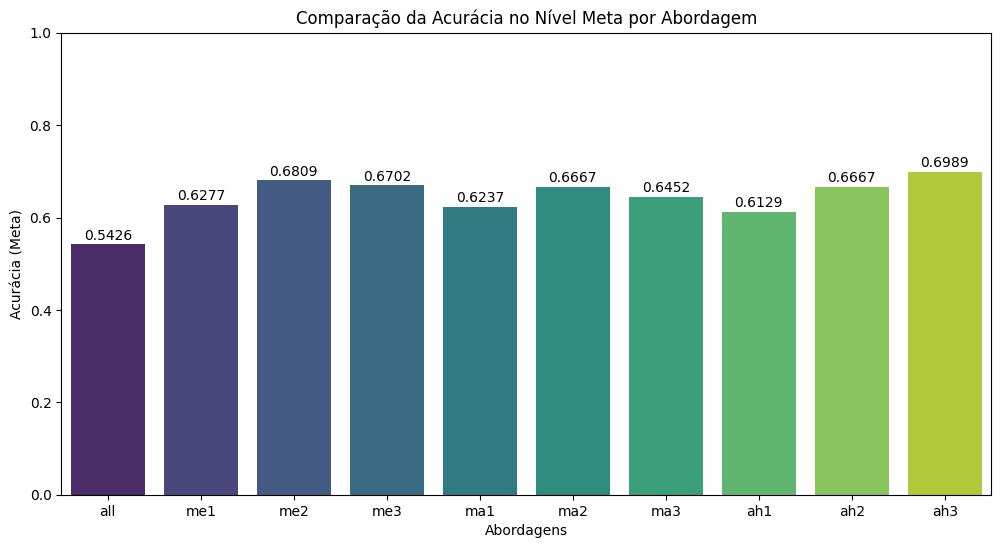

In [30]:

labels = list(meta_models.keys())
acc_meta_values = [meta_models[k]['acc_meta'] for k in labels]

plt.figure(figsize=(12, 6))
sns.barplot(x=labels, y=acc_meta_values, palette="viridis")
plt.title("Comparação da Acurácia no Nível Meta por Abordagem")
plt.xlabel("Abordagens")
plt.ylabel("Acurácia (Meta)")
plt.ylim(0, 1.0)
for i, v in enumerate(acc_meta_values):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontsize=10)
    plt.savefig("results/plots/acc_meta.png", bbox_inches="tight")
plt.show()


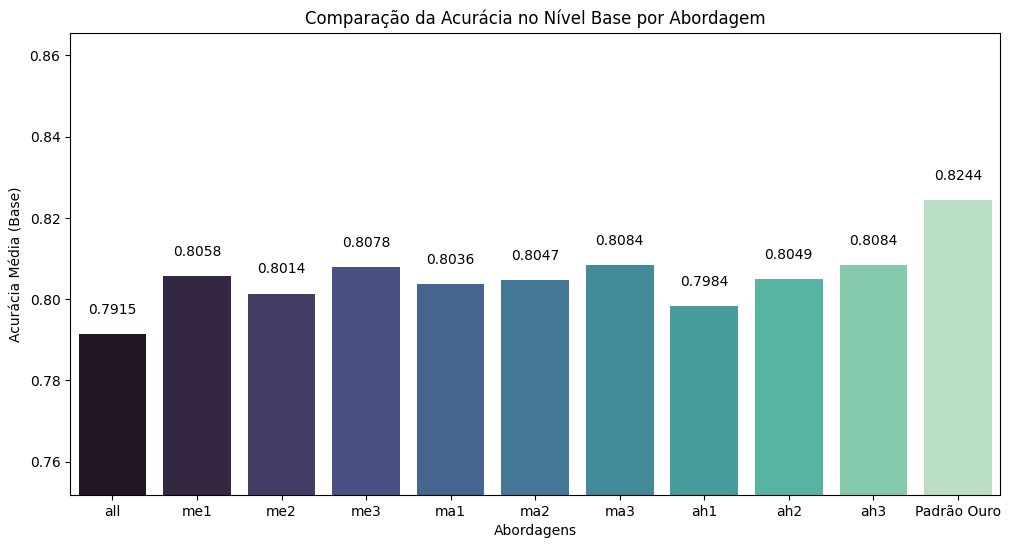

In [31]:
acc_base_real = 0

for i, best in enumerate(dataset['Best']):
    acc_base_real += dataset.iloc[i][best]

acc_base_real = acc_base_real/len(list(dataset['Best']))

acc_base_values = [meta_models[k]['acc_base'] for k in labels]
acc_base_values.append(acc_base_real)

labels_base = labels + ['Padrão Ouro']

plt.figure(figsize=(12, 6))

sns.barplot(
    x=labels_base,
    y=acc_base_values,
    palette="mako"
)

plt.title("Comparação da Acurácia no Nível Base por Abordagem")
plt.xlabel("Abordagens")
plt.ylabel("Acurácia Média (Base)")

plt.ylim(
    min(acc_base_values) * 0.95,
    max(acc_base_values) * 1.05
)

for i, v in enumerate(acc_base_values):
    plt.text(
        i,
        v + 0.005,
        f"{v:.4f}",
        ha='center',
        fontsize=10
    )

    plt.savefig("results/plots/acc_base.png", bbox_inches="tight")
plt.show()